<a href="https://colab.research.google.com/github/Irfansyah001/Machine-Learning-Project-Study/blob/main/223_prak5_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Persiapan Lingkungan dan Library
Menginstal library yang dibutuhkan seperti `kagglehub` dan mengimpor modul dari pandas, scikit-learn, serta TensorFlow untuk membangun dan mengevaluasi model Artificial Neural Network (ANN).

In [ ]:
!pip install kagglehub tensorflow scikit-learn

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import accuracy_score, classification_report


### 2. Mengunduh Dataset
Menggunakan `kagglehub` untuk mengunduh dataset 'Loan Approval Classification' secara langsung ke dalam environment Google Colab.

In [ ]:
import kagglehub
path = kagglehub.dataset_download("taweilo/loan-approval-classification-data")
path

Using Colab cache for faster access to the 'loan-approval-classification-data' dataset.


'/kaggle/input/loan-approval-classification-data'

### 3. Memeriksa Isi Dataset
Mengecek file apa saja yang terdapat di dalam folder dataset yang baru saja diunduh.

In [ ]:
import os
os.listdir(path)

['loan_data.csv']

### 4. Membaca Dataset
Memuat file `loan_data.csv` ke dalam Pandas DataFrame agar bisa diolah lebih lanjut, lalu menampilkan 5 baris pertama.

In [ ]:
df = pd.read_csv(f"{path}/loan_data.csv")
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


### 5. Preprocessing: One-Hot Encoding
Mengubah kolom kategorikal (teks) menjadi angka biner (0 dan 1) menggunakan `pd.get_dummies`. `drop_first=True` digunakan untuk menghindari masalah multikolinearitas (dummy variable trap).

In [ ]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,person_gender_male,...,person_education_Master,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_Yes
0,22.0,71948.0,0,35000.0,16.02,0.49,3.0,561,1,False,...,True,False,False,True,False,False,False,True,False,False
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,0,False,...,False,False,True,False,True,False,False,False,False,True
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,1,False,...,False,False,False,False,False,False,True,False,False,False
3,23.0,79753.0,0,35000.0,15.23,0.44,2.0,675,1,False,...,False,False,False,True,False,False,True,False,False,False
4,24.0,66135.0,1,35000.0,14.27,0.53,4.0,586,1,True,...,True,False,False,True,False,False,True,False,False,False


### 6. Memisahkan Fitur dan Target
Memisahkan kolom target (`loan_status`) yang ingin diprediksi ke variabel `y`, dan sisanya sebagai fitur (data masukan) ke variabel `X`.

In [ ]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

### 7. Membagi Data Training dan Testing
Membagi data menjadi dua bagian: 80% untuk melatih model (training) dan 20% untuk menguji model (testing).

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 8. Standarisasi Data (Scaling)
Mengubah skala fitur-fitur numerik agar memiliki rata-rata 0 dan variansi 1. Hal ini mencegah fitur dengan nilai besar mendominasi proses pembelajaran (mencegah bias) dan membantu model ANN belajar lebih cepat.

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 9. Membangun Arsitektur ANN
Membuat model Neural Network secara berurutan (`Sequential`). Terdiri dari *Input layer*, beberapa *Hidden layer* dengan fungsi aktivasi `relu`, dan *Output layer* dengan aktivasi `sigmoid` (karena ini adalah masalah klasifikasi biner: Disetujui atau Ditolak).

In [ ]:
from tensorflow.keras.layers import Input

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid') # binary classification
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │           736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,409 (5.50 KB)

 Trainable params: 1,409 (5.50 KB)

 Non-trainable params: 0 (0.00 B)

### 10. Melatih Model (Training)
Memulai proses pelatihan model dengan data latih. `validation_split=0.1` memotong 10% data latih untuk dijadikan ujian sementara di setiap iterasi (epoch).

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=16,
    verbose=1
)

Epoch 1/30
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8878 - loss: 0.2465 - val_accuracy: 0.9078 - val_loss: 0.2030
Epoch 2/30
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9069 - loss: 0.2055 - val_accuracy: 0.9117 - val_loss: 0.1902
Epoch 3/30
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9121 - loss: 0.1954 - val_accuracy: 0.9117 - val_loss: 0.1913
Epoch 4/30
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9132 - loss: 0.1905 - val_accuracy: 0.9131 - val_loss: 0.1885
Epoch 5/30
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9154 - loss: 0.1869 - val_accuracy: 0.9083 - val_loss: 0.1883
Epoch 6/30
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9155 - loss: 0.1840 - val_accuracy: 0.9128 - val_loss: 0.1903
Epoch 7/30
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9175 - loss: 0.1816 - val_accuracy: 0.9150 - val_loss: 0.1885
Epoch 8/30
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9196 - loss: 0.1790 - 

### 11. Evaluasi Model
Menggunakan model yang sudah dilatih untuk memprediksi data uji (`X_test`). Probabilitas > 0.5 dianggap sebagai kelas 1 (Disetujui). Kemudian menampilkan performanya melalui laporan klasifikasi.

In [ ]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy:  0.9176666666666666

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95      6990
           1       0.87      0.75      0.80      2010

    accuracy                           0.92      9000
   macro avg       0.90      0.86      0.88      9000
weighted avg       0.92      0.92      0.92      9000



### 12. Visualisasi Hasil Training
Membuat grafik yang membandingkan akurasi dari data training ('Train Acc') dan data validasi ('Val Acc') dari waktu ke waktu (epoch) untuk melihat apakah model belajar dengan baik tanpa *overfitting*.

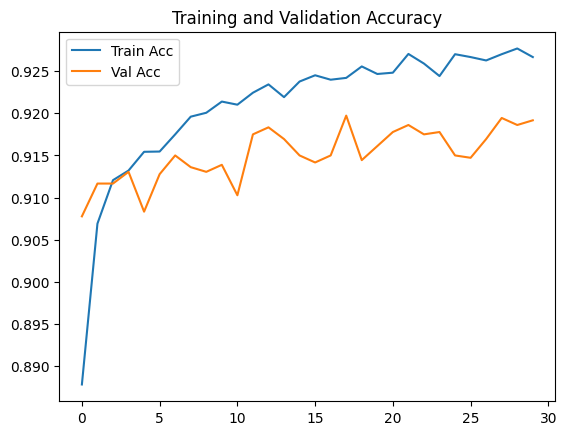

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Training and Validation Accuracy")
plt.show()